# Part 4a: Convolutional Neural Networks with QKeras on the SVHN dataset

In this notebook we train a quantized convolutional neural network (CNN) on the [Street View House Numbers (SVHN)](http://ufldl.stanford.edu/housenumbers/) dataset and deploy it with hls4ml.

The SVHN dataset consists of real-world images of house numbers extracted from Google Street View, cropped to 32×32 RGB pixels. Unlike MNIST it is a harder, more realistic problem: images can contain more than one digit, and the centre digit defines the label. Each image belongs to one of 10 classes (digits 0–9).

![SVHN examples from the test set](../images/part4a_test_images.png)

The dataset has 73,257 training images and 26,032 test images.

In [1]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import time
import sys
from pathlib import Path

sys.path.append('..')
import plotting

import tensorflow as tf
import keras
from keras.layers import Input, MaxPooling2D, Activation, Flatten, Dense, BatchNormalization
from keras.models import Model

from qkeras import QActivation, QDense, QConv2D

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

I0000 00:00:1784185157.802766   11024 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784185161.226675   11024 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784185168.891557   11024 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Fetch the SVHN dataset

We download the SVHN `.mat` files directly from the [official source](http://ufldl.stanford.edu/housenumbers/) and load them with `scipy.io`. The first 75% of the training split is used for training and the remaining 25% for validation.

To save time we do not use the `extra` split (531k additional images); adding it when loading is the most effective way to improve accuracy if you have time.

182040794/182040794 ━━━━━━━━━━━━━━━━━━━━ 55s 0us/step
64275384/64275384 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train: 54942  Val: 18315  Test: 26032  Input shape: (32, 32, 3)


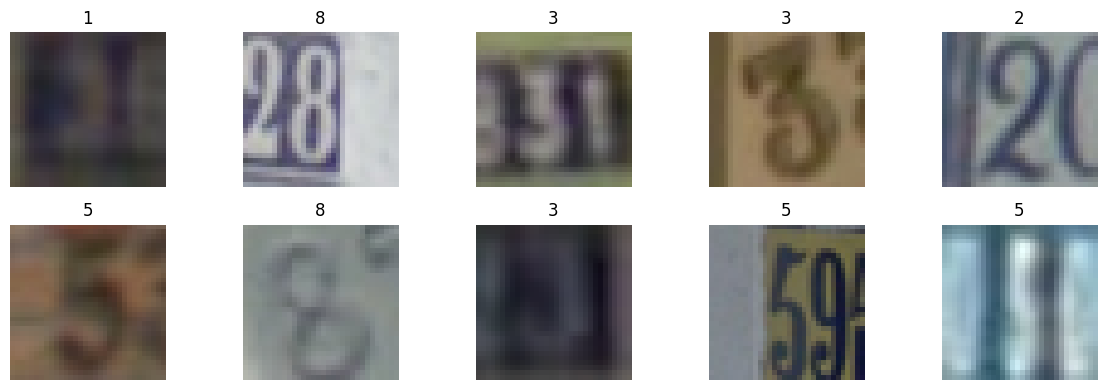

In [2]:
DATA_DIR = Path('../data/svhn')
DATA_DIR.mkdir(parents=True, exist_ok=True)

for fname in ['train_32x32.mat', 'test_32x32.mat']:
    if not (DATA_DIR / fname).exists():
        keras.utils.get_file(
            fname=fname,
            origin=f'http://ufldl.stanford.edu/housenumbers/{fname}',
            cache_dir=str(DATA_DIR.parent),
            cache_subdir='svhn',
        )


def load_mat(path):
    data = scipy.io.loadmat(path)
    X = data['X'].transpose(3, 0, 1, 2).astype(np.float32) / 255.0
    y = data['y'].flatten() % 10  # SVHN labels are 1–10; % 10 maps 10 → 0
    Y = np.eye(10, dtype=np.float32)[y]
    return X, Y


X_all, Y_all = load_mat(DATA_DIR / 'train_32x32.mat')
X_test, Y_test = load_mat(DATA_DIR / 'test_32x32.mat')

# Shuffle before splitting — the .mat file is ordered by class
rng = np.random.default_rng(42)
perm = rng.permutation(len(X_all))
X_all, Y_all = X_all[perm], Y_all[perm]

val_idx = int(0.75 * len(X_all))
X_train, Y_train = X_all[:val_idx], Y_all[:val_idx]
X_val, Y_val = X_all[val_idx:], Y_all[val_idx:]

input_shape = X_train.shape[1:]  # (32, 32, 3)
n_classes = 10
train_size = len(X_train)

print(f'Train: {train_size}  Val: {len(X_val)}  Test: {len(X_test)}  Input shape: {input_shape}')

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(str(np.argmax(Y_train[i])))
    ax.axis('off')
plt.tight_layout()

## Build data pipelines

Images are normalised to [0, 1] and labels are one-hot encoded during loading. The data is shuffled with a fixed seed before the 75/25 train/validation split to ensure a balanced class distribution in both sets.

The training and validation sets are wrapped in `tf.data` pipelines. Chaining `.shuffle` → `.batch` → `.prefetch` ensures the next batch is prepared on the CPU while the GPU trains on the current one. `tf.data.AUTOTUNE` lets TensorFlow select the number of parallel threads for `.prefetch` automatically at runtime.

The test set remains as numpy arrays for direct use with sklearn and hls4ml.

In [3]:
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 128

train_data = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(4096).batch(batch_size).prefetch(AUTOTUNE)
val_data = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(batch_size).prefetch(AUTOTUNE)

print(f'Test set: X={X_test.shape}, Y={Y_test.shape}')

E0000 00:00:1784185253.530615   11024 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1784185253.531643   11024 cpu_allocator_impl.cc:82] Allocation of 675127296 exceeds 10% of free system memory.


Test set: X=(26032, 32, 32, 3), Y=(26032, 10)


## Define the quantized model

We use QKeras to train a quantized CNN. Each convolutional block consists of a `QConv2D` layer with 6-bit quantized weights, followed by a standard `BatchNormalization` and a 6-bit quantized ReLU activation (`quantized_relu(6)`).

In [4]:
filters_per_conv_layer = [16, 16, 24]
neurons_per_dense_layer = [42, 64]

x = x_in = Input(shape=input_shape)

for i, f in enumerate(filters_per_conv_layer):
    x = QConv2D(
        int(f),
        kernel_size=(3, 3),
        kernel_quantizer='quantized_bits(6,0,alpha=1)',
        bias_quantizer='quantized_bits(6,0,alpha=1)',
        use_bias=True,
        name=f'conv_{i}',
    )(x)
    x = BatchNormalization(name=f'bn_conv_{i}')(x)
    x = QActivation('quantized_relu(6)', name=f'conv_act_{i}')(x)
    x = MaxPooling2D(pool_size=(2, 2), name=f'pool_{i}')(x)
x = Flatten()(x)

for i, n in enumerate(neurons_per_dense_layer):
    x = QDense(
        n,
        kernel_quantizer='quantized_bits(6,0,alpha=1)',
        name=f'dense_{i}',
        use_bias=False,
    )(x)
    x = BatchNormalization(name=f'bn_dense_{i}')(x)
    x = QActivation('quantized_relu(6)', name=f'dense_act_{i}')(x)

x = Dense(n_classes, name='output_dense')(x)
x_out = Activation('softmax', name='output_softmax')(x)

model = Model(inputs=[x_in], outputs=[x_out], name='qkeras_cnn')
model.summary()

Model: "qkeras_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0 (QConv2D)                │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_0 (BatchNormalization)  │ (None, 30, 30, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_0 (QActivation)        │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_0 (MaxPooling2D)           │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (QConv2D)                │ (None, 13, 13, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 13, 13, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (QActivation)        │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (QConv2D)                │ (None, 4, 4, 24)       │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (QActivation)        │ (None, 4, 4, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (QDense)                │ (None, 42)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_0 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_act_0 (QActivation)       │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (QDense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_act_1 (QActivation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,266 (55.73 KB)

 Trainable params: 13,942 (54.46 KB)

 Non-trainable params: 324 (1.27 KB)

## Train the model

**Note on accuracy**: the accuracy achieved in this notebook is lower than the one reported in the [hls4ml CNN paper](https://arxiv.org/abs/2101.05108), because we only train on the 73k-image training split rather than the 531k-image `extra` split used in the paper. 

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-7, amsgrad=True),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'],
)
callbacks = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]
t0 = time.time()
model.fit(train_data, epochs=20, validation_data=val_data, callbacks=callbacks)
print(f'\nTraining took {(time.time() - t0) / 60:.1f} minutes')
os.makedirs('../models', exist_ok=True)
model.save('../models/qkeras_cnn_part4a.keras')

Epoch 1/20


W0000 00:00:1784185254.508015   11024 cpu_allocator_impl.cc:82] Allocation of 675127296 exceeds 10% of free system memory.


430/430 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.5629 - loss: 1.2996 - val_accuracy: 0.7338 - val_loss: 0.8382 - learning_rate: 0.0050
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8248 - loss: 0.5701 - val_accuracy: 0.7872 - val_loss: 0.6571 - learning_rate: 0.0050
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.8630 - loss: 0.4471 - val_accuracy: 0.8188 - val_loss: 0.5780 - learning_rate: 0.0050
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8795 - loss: 0.3967 - val_accuracy: 0.8271 - val_loss: 0.5494 - learning_rate: 0.0050
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.8875 - loss: 0.3653 - val_accuracy: 0.8564 - val_loss: 0.4638 - learning_rate: 0.0050
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8954 - loss: 0.3411 - val_accuracy: 0.8198 - val_loss: 0.5654 - learning_rate: 0.0050
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8999 - loss: 0.3235

## Performance

In [6]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print(f'QKeras accuracy: {accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)):.4f}')

814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
QKeras accuracy: 0.8941


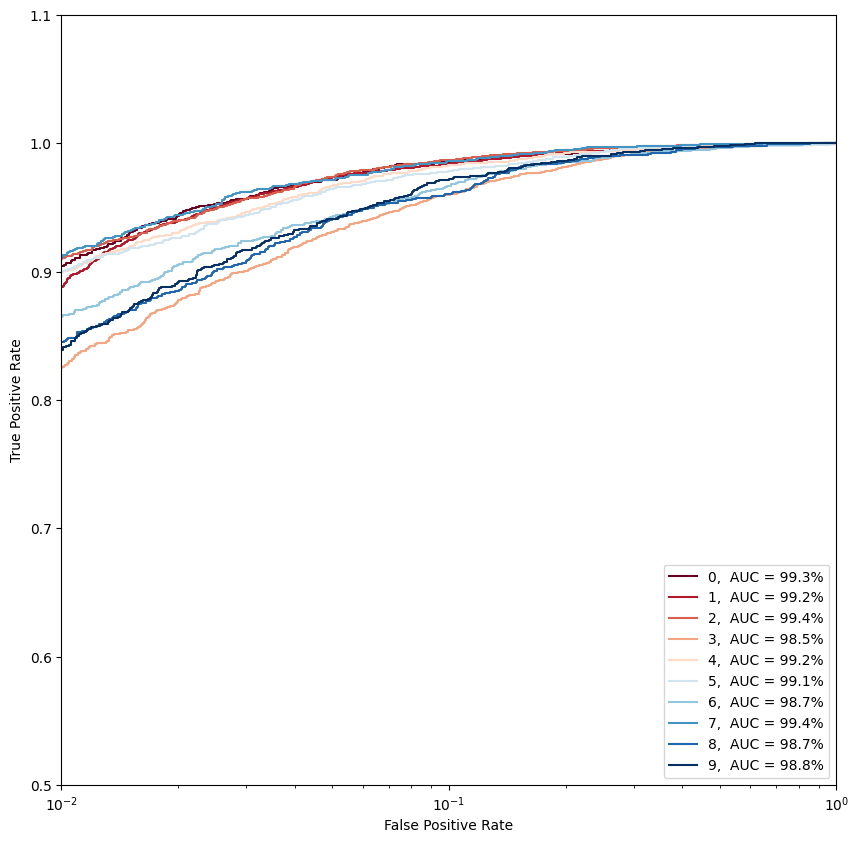

In [7]:
from sklearn import metrics

colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', '#fddbc7', '#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061']

fig, ax = plt.subplots(figsize=(10, 10))
for i in range(n_classes):
    fpr, tpr, _ = metrics.roc_curve(Y_test[:, i], y_pred[:, i])
    auc = metrics.auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{i},  AUC = {auc*100:.1f}%', linewidth=1.5, c=colors[i])

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim(0.01, 1.0)
ax.set_ylim(0.5, 1.1)
ax.semilogx()
ax.legend(loc='lower right')

## Convolutions in hls4ml

hls4ml supports two I/O modes for neural networks:

- **`io_parallel`**: All inputs arrive simultaneously. Suitable for small models, when all activations fit into registers.
- **`io_stream`**: Data flows through the network one element at a time via FIFO buffers. Required for larger CNNs, when the full feature maps are too large to hold in registers. Shift registers maintain a sliding window of `kernel_height − 1` rows, feeding the convolution kernel one pixel at a time.

See the [hls4ml documentation](https://fastmachinelearning.org/hls4ml/concepts.html) for more details.

![Conv2D stream implementation](../images/part4a_conv2d_animation.gif)

**Note on softmax precision:** using `auto` precision for the output of the last dense layer can produce accumulators wider than the softmax look-up tables can handle. We cap this manually with `fixed<16,6,RND,SAT>`.

In [8]:
import hls4ml

hls_config = hls4ml.utils.config_from_keras_model(
    model, granularity='name', backend='Vitis', default_precision='fixed<16,6>', max_precision='fixed<18,8>'
)
hls_config['LayerName']['output_dense']['Precision']['result'] = 'fixed<16,6,RND,SAT>'
plotting.print_dict(hls_config)

hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=hls_config,
    backend='Vitis',
    output_dir='../hls4ml_prjs/hls4ml_prj_cnn_part4a',
    part='xcu200-fsgd2104-2-e',
    io_type='io_stream',
)
hls_model.compile()

Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package da4ml is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer bn_conv_0
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer bn_conv_1
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer bn_conv_2
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer bn_dense_0
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer bn_dense_1
Model
  Precision
    default:         fixed<16,6>
    maximum:         fixed<18,8>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_layer
    Trace:           False
    Precision
      result:        auto
  conv_0
    Trace:           False
    Precision
      result:        auto
      weight:        fixed<6,1,TRN,WRAP,0>
      bi

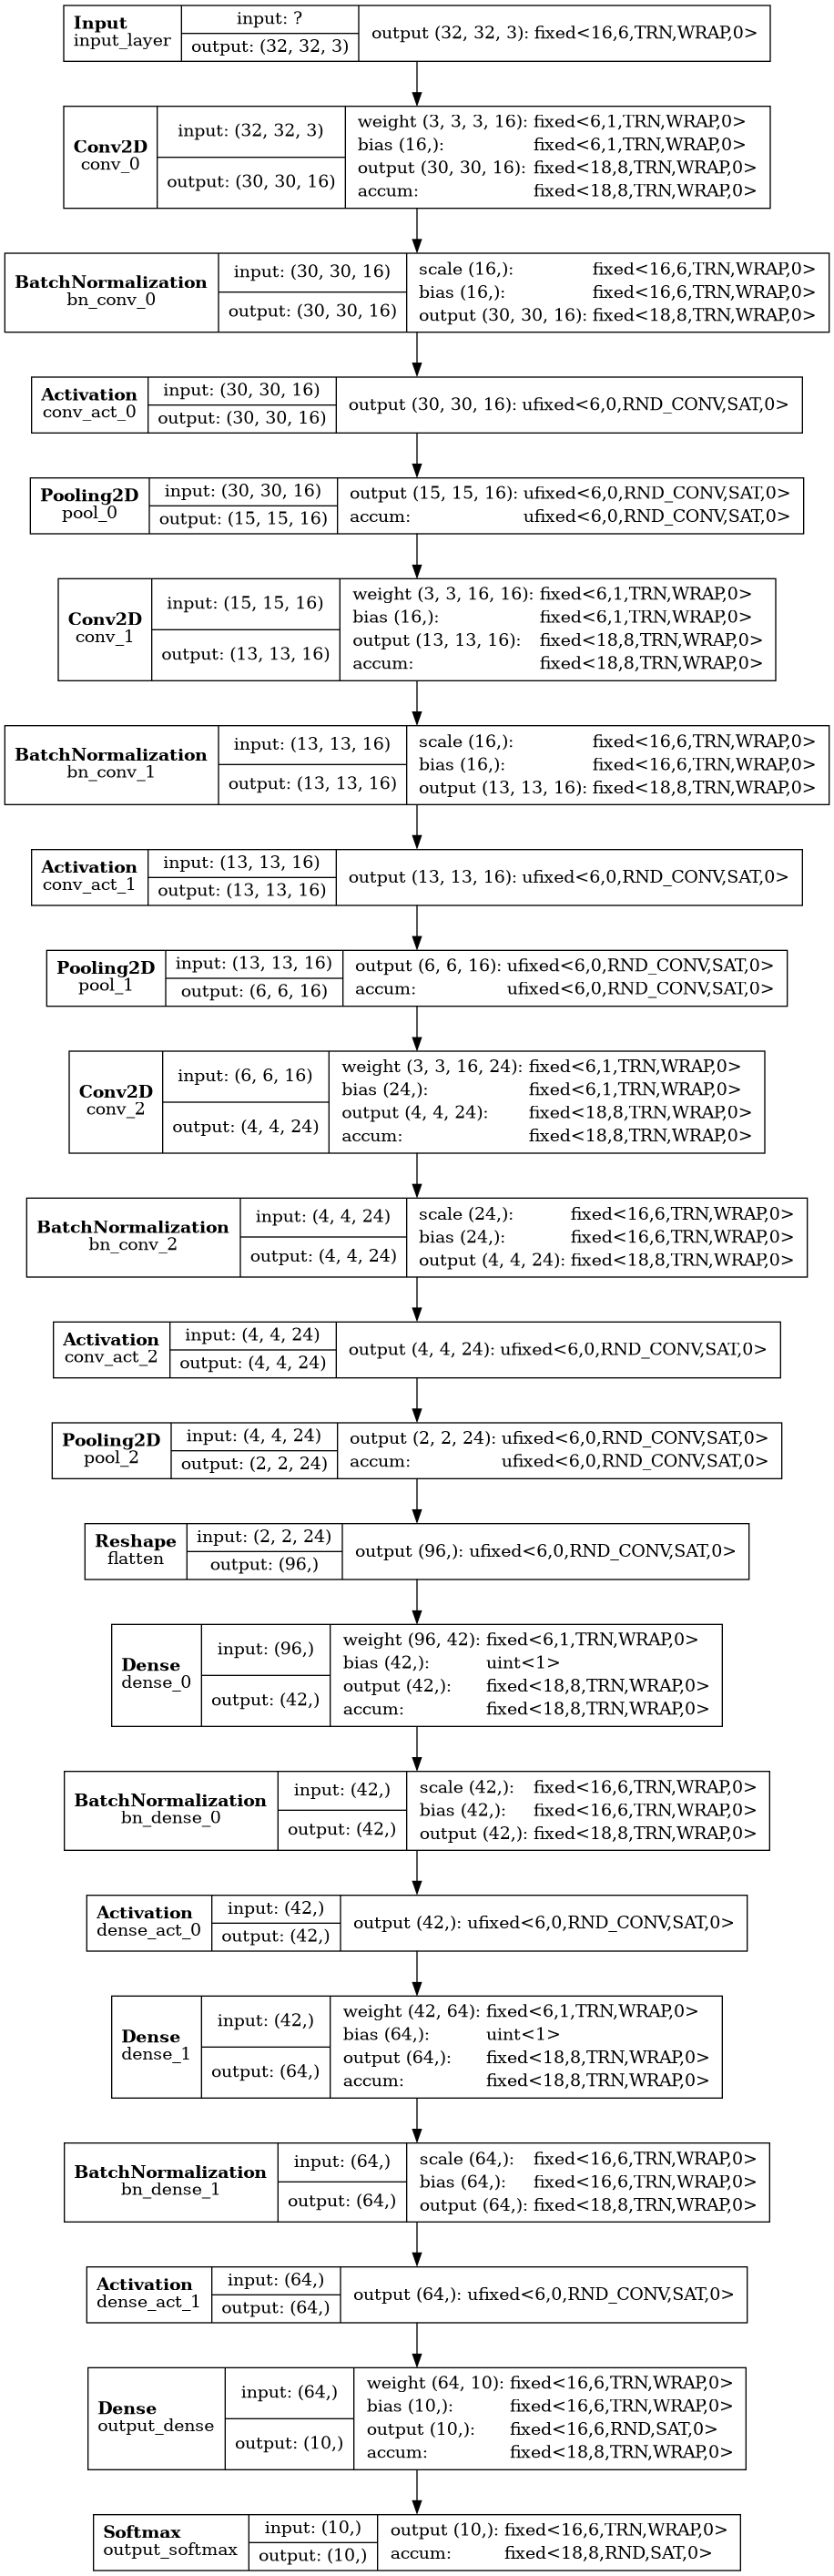

In [9]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Bit-accurate emulation

We run `hls_model.predict` on a subset of the test set (the full set takes a long time CNNs) to confirm that the fixed-point hls4ml model achieves satisfactory performance, before kicing off FPGA synthesis.

In [10]:
X_test_reduced = np.ascontiguousarray(X_test[:3000])
Y_test_reduced = np.array(Y_test[:3000])

y_pred_reduced = model.predict(X_test_reduced)
y_pred_hls = hls_model.predict(X_test_reduced)

print(f'QKeras accuracy : {accuracy_score(np.argmax(Y_test_reduced, axis=1), np.argmax(y_pred_reduced, axis=1)):.4f}')
print(f'hls4ml accuracy : {accuracy_score(np.argmax(Y_test_reduced, axis=1), np.argmax(y_pred_hls,     axis=1)):.4f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
QKeras accuracy : 0.8827
hls4ml accuracy : 0.8843


## Synthesis

Run Vitis HLS C-synthesis and Vivado RTL synthesis.

**This can take around an hour.**

In [ ]:
hls_model.build(csim=False, synth=True, vsynth=True)

## Reports

Extract latency and resource numbers from the HLS and Vivado synthesis reports.

In [ ]:
from pathlib import Path
import pprint


def getReports(indir):
    data = {}
    report_vsynth = Path(f'{indir}/vivado_synth.rpt')
    report_csynth = Path(f'{indir}/myproject_prj/solution1/syn/report/myproject_csynth.rpt')
    if not (report_vsynth.is_file() and report_csynth.is_file()):
        print(f'No reports found in {indir}')
        return data
    with report_vsynth.open() as f:
        lines = np.array(f.readlines())
        data['lut'] = int(lines[np.array(['CLB LUTs*' in l for l in lines])][0].split('|')[2])
        data['ff'] = int(lines[np.array(['CLB Registers' in l for l in lines])][0].split('|')[2])
        data['bram'] = float(lines[np.array(['Block RAM Tile' in l for l in lines])][0].split('|')[2])
        data['dsp'] = int(lines[np.array(['DSPs' in l for l in lines])][0].split('|')[2])
        data['lut_%'] = float(lines[np.array(['CLB LUTs*' in l for l in lines])][0].split('|')[6])
        data['ff_%'] = float(lines[np.array(['CLB Registers' in l for l in lines])][0].split('|')[6])
        data['bram_%'] = float(lines[np.array(['Block RAM Tile' in l for l in lines])][0].split('|')[6])
        data['dsp_%'] = float(lines[np.array(['DSPs' in l for l in lines])][0].split('|')[6])
    with report_csynth.open() as f:
        lines = np.array(f.readlines())
        lat_line = lines[np.argwhere(np.array(['Latency (cycles)' in l for l in lines])).flatten()[0] + 3]
        data['latency_clks'] = int(lat_line.split('|')[2])
        data['latency_us'] = float(lat_line.split('|')[2]) * 5.0 / 1000.0
        data['latency_ii'] = int(lat_line.split('|')[6])
    return data


pprint.pprint(getReports('../hls4ml_prjs/hls4ml_prj_cnn_part4a'))

## Further reading

For more details, see:

- Aarrestad et al., "Fast convolutional neural networks on FPGAs with hls4ml", Mach. Learn. Sci. Tech. 2(4):045015 (2021), [arXiv:2101.05108](https://arxiv.org/abs/2101.05108)
- Ghielmetti et al., "Real-time semantic segmentation on FPGAs for autonomous vehicles with hls4ml", Mach. Learn. Sci. Tech. (2022), [arXiv:2205.07690](https://arxiv.org/abs/2205.07690)